## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

from randomness import *
from df_metrics import *
from simulation_exact import *
from utils import *
from data_analysis import *
from main import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from joblib import Parallel, delayed
from itertools import product

#seed = 42
#np.random.seed(seed)
#rng = np.random.default_rng(seed)

## Learning parameters 

In [32]:
use_loss = 'hinge' #'log' or 'hinge' or 'squared_hinge' 
sigma_loss = 1.0 
c = 1.0 # choose c without scaling 
show_plots = False # set to True to see plots of the binary search
is_throw = False # set to True to throw out points outside margin --> only when loss is lipschitz. 
k = None # if none will be set based on data max norm
k_coef = 1.0 # coefficient to multiply k with
fit_intercept = True # whether to fit intercept in SVM model
ds = [2, 4, 8, 16, 32, 64] # dimensions to run experiments on
T = 500  # number of trials

## Generate V's

In [4]:
def generate_v_data_1(n_neg, n_pos, rng = None):
    return np.ones(n_neg+n_pos)

In [5]:
def generate_v_data_2(n_neg, n_pos, rng = None):
    return rng.normal(loc=1.0, scale=1.0, size=(n_pos + n_neg, 1)) # label 1 

In [6]:
# correlation between y and v
def generate_v_data_3(n_neg, n_pos, rng = None):
    v_neg = 2 * np.ones(n_neg)
    v_pos = np.ones(n_pos)
    v = np.concatenate([v_neg, v_pos])
    return v

In [7]:
# correlation between y and v
def generate_v_data_4(n_neg, n_pos, rng = None):
    v_neg = 0.5 * np.ones(n_neg)
    v_pos = np.ones(n_pos)
    v = np.concatenate([v_neg, v_pos])
    return v

## throw check

In [ ]:
# # run exact sisigmalation
# # returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# # utility = welfare - payment
# # welfare = allocation * true_v
# # critical_v = payment 

# def compute_metrics_throw(t):
#     dfs = []
#     for d in ds:
#         for v in vs:
#             mu_neg_vector = np.concatenate(([mu_neg], np.zeros(d - 1)))
#             mu_pos_vector = np.concatenate(([mu_pos], np.zeros(d - 1)))
#             seed = hash((t, d, v)) % (2**32)
#             rng = np.random.default_rng(seed)
#             x, y, v_vector = generate_gaus_data_v(v, n_pos, n_neg , mu_pos_vector, mu_neg_vector, sigma_pos/ np.sqrt(d), sigma_neg/ np.sqrt(d), rng, d)
#             x_val, y_val, _ = generate_gaus_data_v(v, n_val_pos, n_val_neg, mu_pos_vector, mu_neg_vector, sigma_pos/ np.sqrt(d), sigma_neg/ np.sqrt(d), rng, d)
                
#             assert np.all(v_vector > 0), "v must be nonnegative"
#             for x_0 in xs:
#                 x[0] = np.concatenate(([x_0], np.zeros(d - 1)))
#                 k = (np.linalg.norm(x, axis=1).max())
#                 df_exact, svm_model = run_exact(x, y, v_vector, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
#                                         is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
                
#                 w = svm_model.coef_.ravel()
#                 b = svm_model.intercept_
#                 # compute margins: y * f(x)
#                 decision_values = x @ w + b
#                 margin = y * decision_values

#                 df_exact['t'] = t
#                 df_exact['d'] = d
#                 df_exact['v'] = v
#                 # df_exact['x'] = list(x[df_exact['agent'].astype(int)])
#                 df_exact['valid_acc'] = svm_model.score(x_val,y_val)
#                 df_exact['label'] = y[df_exact['agent'].astype(int)]
#                 df_exact['k'] = k
#                 # df_exact['x_0'] = x_0
#                 df_exact['margin'] = margin[df_exact['agent'].astype(int)]
#                 df_exact['x_beta3'] =1 +  3 * ((k*k_coef)**2 * (df_exact['true_v'].astype(int)) * sigma_loss) / (2 * (1.0 / (c/ sum(v_vector))))
#                 df_exact['x_beta_'] =1 +  ((k*k_coef)**2 * (df_exact['true_v'].astype(int)) * sigma_loss) / (2 * (1.0 / (c/ sum(v_vector))))
#                 df_exact['x_beta_2'] =1 +  ((k*k_coef)**2 * (df_exact['true_v'].astype(int))**2 * sigma_loss) / (2 * (1.0 / (c/ sum(v_vector))))
#                 dfs.append(df_exact)
#     return pd.concat(dfs, ignore_index=True)

In [ ]:
# # take one point with v >1 and move it on x-axis \in [1+beta, max] to see when it effects the model
# is_throw = True
# # choose parameters 
# n_pos = 50 # number of data points in a sample with label 1
# n_neg = 50 # number of data points in a sample with label -1
# n_val_pos = 200
# n_val_neg = 200
# sigma_pos = 1.0
# sigma_neg = 1.0
# mu_pos = 1.0
# mu_neg = -1.0
# xs = [-0.666667] # different sigmas to run the experiments on
# T = 200
# vs =  np.linspace(10, 0.1, 41)
# vs = [vs[-13]]
# ds = [16] #,32,64]

# mega_df_throw = compute_metrics_throw(7)

# # mega_df_throw = pd.concat(  
# #     Parallel(n_jobs=-1, backend="loky")(
# #         delayed(compute_metrics_throw)(t) for t in range(T)
# #         ), 
# #         ignore_index=True
# # )

# #  print((k, (1.0 / (c/ sum(v_vector))), sum(v_vector)))
# #  print(k, lam, c, sum(v))



## constant mu and changing v ratio

In [9]:
def generate_gaus_data_v(v, n_pos, n_neg, mu_pos, mu_neg, sigma_pos, sigma_neg, rng, d=1):
    X_neg = rng.normal(loc=mu_neg, scale=sigma_neg, size=(n_neg, d)) # label -1 
    X_pos = rng.normal(loc=mu_pos, scale=sigma_pos, size=(n_pos, d)) # label 1 
    X = np.vstack([X_neg, X_pos])
    y = np.concatenate([-1 * np.ones(n_neg),np.ones(n_pos)])

    v_vector = np.concatenate([v * np.ones(n_neg),np.ones(n_pos)])
    return X, y, v_vector

In [10]:
# choose parameters 
n_pos = 50 # number of data points in a sample with label 1
n_neg = 50 # number of data points in a sample with label -1
n_val_pos = 200
n_val_neg = 200
sigma_pos = 1.0
sigma_neg = 1.0
mu_pos = 1.0
mu_neg = -1.0
vs = np.linspace(0.1, 10, 21) # different sigmas to run the experiments on

In [11]:
# run exact sisigmalation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_gaus_v(t):
    dfs = []
    for d in ds:
        for v in vs:
            mu_neg_vector = np.concatenate(([mu_neg], np.zeros(d - 1)))
            mu_pos_vector = np.concatenate(([mu_pos], np.zeros(d - 1)))
            seed = hash((t, d, v)) % (2**32)
            rng = np.random.default_rng(seed)
            x, y, v_vector = generate_gaus_data_v(v, n_pos, n_neg, mu_pos_vector, mu_neg_vector, sigma_pos/ np.sqrt(d), sigma_neg/ np.sqrt(d), rng, d)
            assert np.all(v_vector > 0), "v must be nonnegative"
            k = (np.linalg.norm(x, axis=1).max())
            x_val, y_val, _ = generate_gaus_data_v(v, n_val_pos, n_val_neg, mu_pos_vector, mu_neg_vector, sigma_pos/ np.sqrt(d), sigma_neg/ np.sqrt(d), rng, d)
            
            df_exact, svm_model = run_exact(x, y, v_vector, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
            w = svm_model.coef_.ravel()
            b = svm_model.intercept_
            # compute margins: y * f(x)
            decision_values = x @ w + b
            margin = y * decision_values
            df_exact['t'] = t
            df_exact['d'] = d
            df_exact['v'] = v
            df_exact['valid_acc'] = svm_model.score(x_val,y_val)
            df_exact['label'] = y[df_exact['agent'].astype(int)]
            df_exact['margin'] = margin[df_exact['agent'].astype(int)]
            df_exact['k'] = k
            dfs.append(df_exact)
    return pd.concat(dfs, ignore_index=True)

In [ ]:
mega_df_gaus_v = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_v)(t) for t in range(T)
        ), 
        ignore_index=True
)

In [19]:
mega_df_gaus_v[(mega_df_gaus_v['allocation'] == 0) & (mega_df_gaus_v['is_relevant'] == 1)]

,agent,allocation,true_v,critical_v,welfare,utility,is_relevant,is_throw,t,d,v,valid_acc,label,margin,k


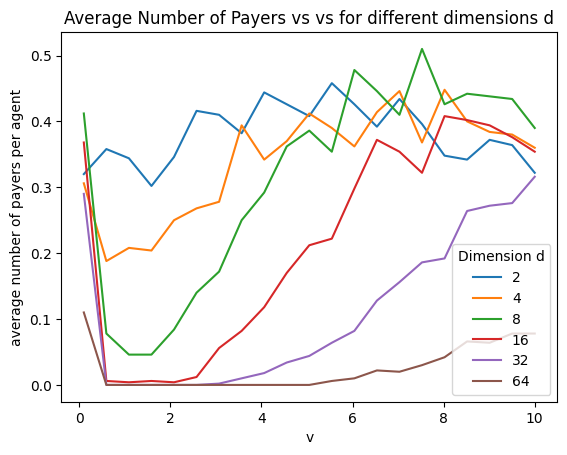

In [10]:
var = 'v'
plot_mean_num_payers(mega_df_gaus_v, var, labels = [1, -1])

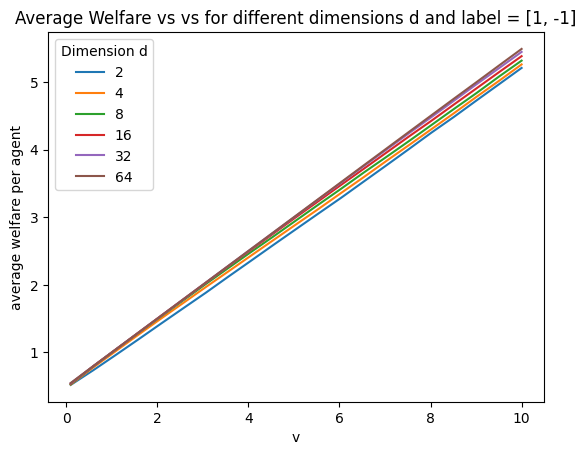

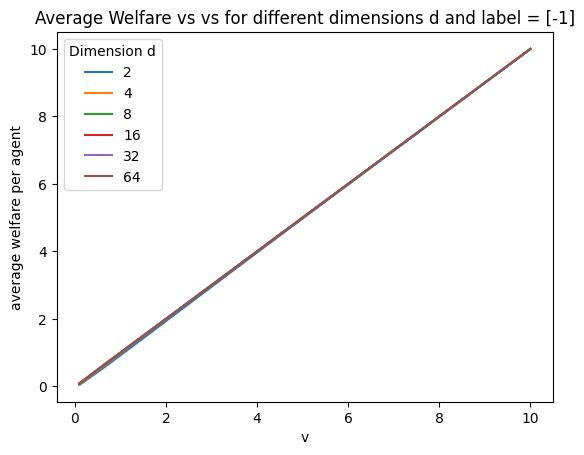

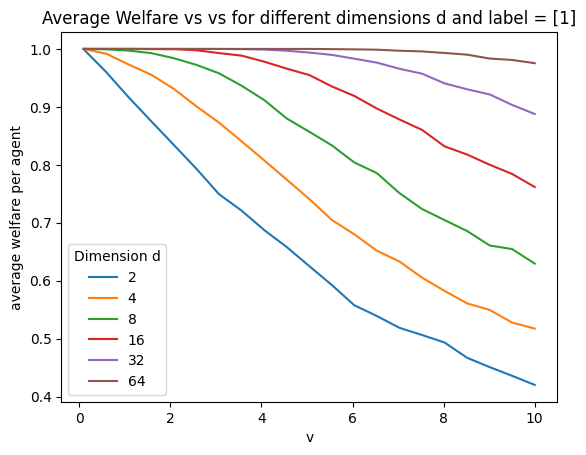

In [11]:
plot_mean_welfare(mega_df_gaus_v, var, labels = [1, -1])
plot_mean_welfare(mega_df_gaus_v, var, labels = [-1])
plot_mean_welfare(mega_df_gaus_v, var, labels = [1])

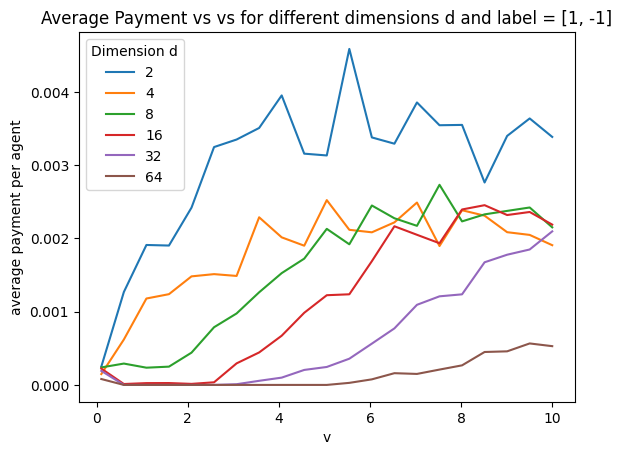

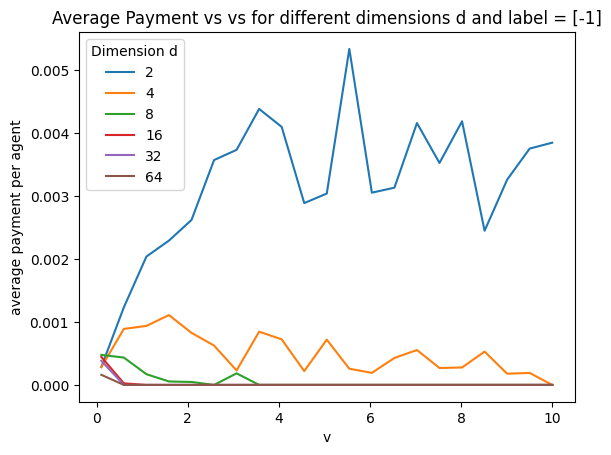

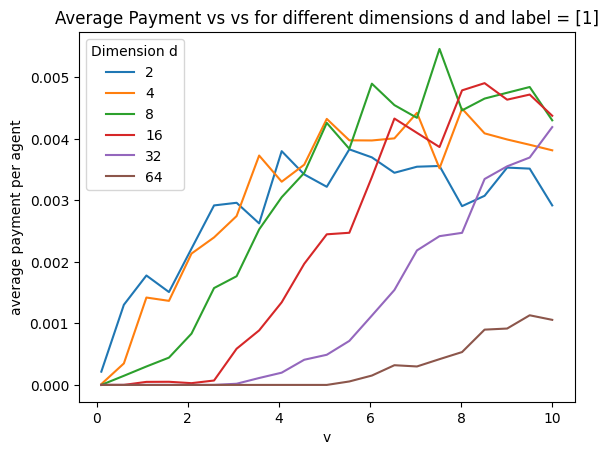

In [12]:
plot_mean_payment(mega_df_gaus_v, var, labels = [1, -1])
plot_mean_payment(mega_df_gaus_v, var, labels = [-1])
plot_mean_payment(mega_df_gaus_v, var, labels = [1])

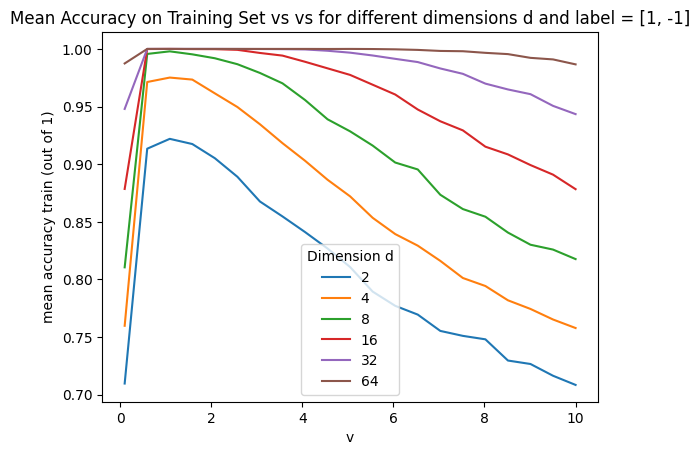

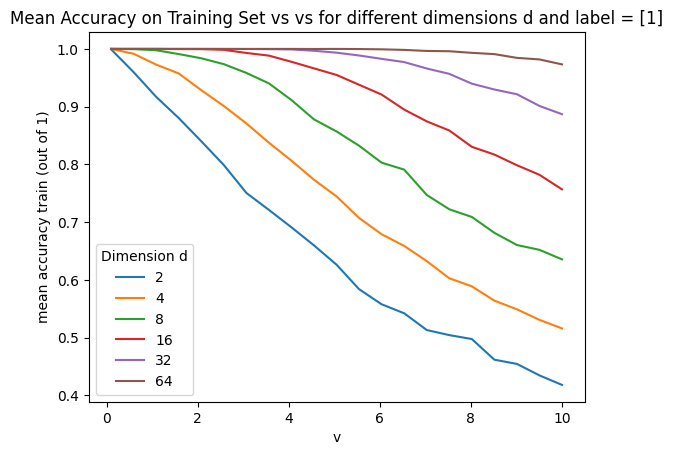

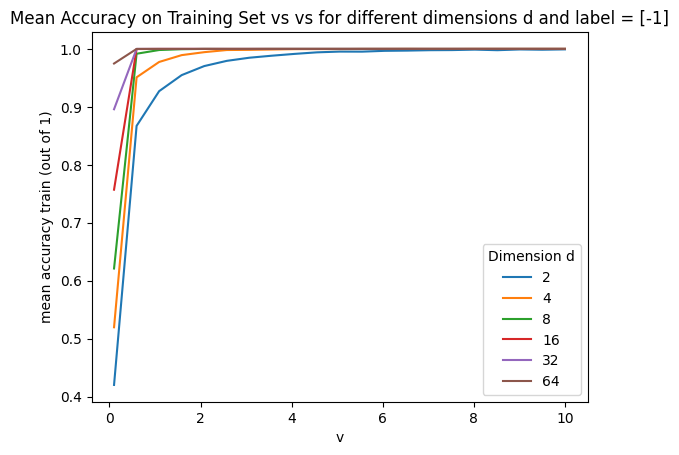

In [29]:
plot_mean_accuracy_train(mega_df_gaus_v, var, labels = [1, -1])
plot_mean_accuracy_train(mega_df_gaus_v, var, labels = [1])
plot_mean_accuracy_train(mega_df_gaus_v, var, labels = [ -1])

## Run for Beta distrbuted data : change beta negative 

In [4]:
# change m for different betas 
# non need to learn use w = 0 
# d = v = 1

In [ ]:
def generate_beta_data(n_neg, n_pos, alpha_neg, beta_neg, 
                       alpha_pos, beta_pos, rng, d=1):
    # Sample negative points
    neg_samples = rng.beta(alpha_neg, beta_neg, size=(n_neg, d))
    
    # Sample positive points
    pos_samples = rng.beta(alpha_pos, beta_pos, size=(n_pos, d))
    
    # Combine and return
    X = np.vstack([neg_samples, pos_samples])

    y = np.concatenate([-1 * np.ones(n_neg), np.ones(n_pos)])

    v = generate_v_data(n_neg, n_pos, rng)

    return X, y, v

In [ ]:
# 1. choose n for training and validation  
n_pos = 50 # number of data points in a sample with label 1
n_neg = 50 # number of data points in a sample with label -1
n_val_pos = 200
n_val_neg = 200

# 2. distrbution parameters 
alpha_neg = 5
beta_neg = 2
alpha_pos = 2
beta_pos = 5
betas = np.linspace(10,0.5, 21) # different sigmas to run the experiments on


In [ ]:
# 3. run exact sisigmalation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_beta(t):
    dfs = []
    for d in ds:
        for beta in betas:
            seed = hash((t, d, beta)) % (2**32)
            rng = np.random.default_rng(seed)
            #beta_neg = alpha_pos = beta 
            x, y, v =  generate_beta_data(n_neg, n_pos, alpha_neg, beta, alpha_pos, beta_pos, rng, d)
            x_val, y_val, _ = generate_beta_data(n_val_neg, n_val_pos, alpha_neg, beta, alpha_pos, beta_pos, rng, d)
            
            df_exact, svm_model = run_exact(x, y, v, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
            df_exact['t'] = t
            df_exact['d'] = d
            df_exact['beta_neg'] = beta
            df_exact['valid_acc'] = svm_model.score(x_val,y_val)
            df_exact['label'] = y[df_exact['agent'].astype(int)]
            dfs.append(df_exact)

    return pd.concat(dfs, ignore_index=True)

# Run for gaussians

In [4]:
def generate_gaus_data(n_pos, n_neg, mu_pos, mu_neg, sigma_pos, sigma_neg, rng, d=1):
    X_neg = rng.normal(loc=mu_neg, scale=sigma_neg, size=(n_neg, d)) # label -1 
    X_pos = rng.normal(loc=mu_pos, scale=sigma_pos, size=(n_pos, d)) # label 1 
    X = np.vstack([X_neg, X_pos])
    y = np.concatenate([-1 * np.ones(n_neg),np.ones(n_pos)])

    v = np.concatenate([np.ones(n_pos + n_neg)])  # generate_v_data(n_neg, n_pos, rng)
    return X, y, v

## Run for two gaussians: fixed sigmas, changing mus : gaus_1

In [28]:
# choose parameters 
n_pos = 50 # number of data points in a sample with label 1
n_neg = 50 # number of data points in a sample with label -1
n_val_pos = 200
n_val_neg = 200
sigma_pos = 1.0
sigma_neg = 1.0
mus = np.linspace(3, 0, 31) # different sigmas to run the experiments on

In [11]:
# run exact sisigmalation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_gaus_1(t):
    dfs = []
    for d in ds:
        for mu_scalar in mus:
            mu = np.concatenate(([mu_scalar], np.zeros(d - 1)))
            seed = hash((t, d, mu_scalar)) % (2**32)
            rng = np.random.default_rng(seed)
            x, y, v = generate_gaus_data(n_pos, n_neg, mu, -mu, sigma_pos/ np.sqrt(d), sigma_neg/ np.sqrt(d), rng, d)
            x_val, y_val, _ = generate_gaus_data(n_val_pos, n_val_neg, mu, -mu, sigma_pos/ np.sqrt(d), sigma_neg/ np.sqrt(d), rng, d)
            
            df_exact, svm_model = run_exact(x, y, v, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
            df_exact['t'] = t
            df_exact['d'] = d
            df_exact['mu'] = mu_scalar
            df_exact['valid_acc'] = svm_model.score(x_val,y_val)
            df_exact['label'] = y[df_exact['agent'].astype(int)]
            dfs.append(df_exact)

    return pd.concat(dfs, ignore_index=True)

## Run for two gaussians: fixed mus, changing sigmas : gaus_2

In [ ]:
# play with both sigmas , d = 1, change m 

In [38]:
# choose parameters 
n_pos = 50 # number of data points in a sample with label 1
n_neg = 50 # number of data points in a sample with label -1
n_val_pos = 200
n_val_neg = 200

mu_pos_scalar = 0.5 # class 1 mean
mu_neg_scalar = -0.5 # class -1 mean
sigma_pos = 1.0
sigma_neg = 1.0
sigmas = np.linspace(1.5, 0.1, 11) # different sigmas to run the experiments on

In [ ]:
# run exact sisigmalation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_gaus_2(t):
    dfs = []
    for d in ds:
        mu_pos =  np.concatenate(([mu_pos_scalar], np.zeros(d - 1)))
        mu_neg =  np.concatenate(([mu_neg_scalar], np.zeros(d - 1)))
        for sigma in sigmas:
            seed = hash((t, d, sigma)) % (2**32)
            rng = np.random.default_rng(seed)
            x, y, v =  generate_gaus_data(n_pos, n_neg, mu_pos, mu_neg, sigma, sigma_neg, rng, d)
            x_val, y_val, _ =  generate_gaus_data(n_val_pos, n_val_neg, mu_pos, mu_neg, sigma, sigma_neg, rng, d)
            
            df_exact, svm_model = run_exact(x, y, v, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
            df_exact['t'] = t
            df_exact['d'] = d
            df_exact['sigma_pos'] = sigma
            df_exact['valid_acc'] = svm_model.score(x_val,y_val)
            df_exact['label'] = y[df_exact['agent'].astype(int)]
            dfs.append(df_exact)

    return pd.concat(dfs, ignore_index=True)

# Run experiments

In [12]:
def generate_v_data(n_neg, n_pos, rng = None):
    return generate_v_data_4(n_neg, n_pos, rng = rng) # imbalanced constant (neg = 2,pos = 1)
    # return generate_v_data_2(n_neg, n_pos, rng = rng) #mean =1 , sigma =1 gaussian
    #return generate_v_data_1(n_neg, n_pos, rng = rng) # constant 1


In [ ]:
mega_df_beta_2 = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_beta)(t) for t in range(T)
        ), 
        ignore_index=True
)

In [ ]:
mega_df_beta = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_beta)(t) for t in range(T)
        ), 
        ignore_index=True
)

In [ ]:
mega_df_mu = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_1)(t) for t in range(T)
        ), 
        ignore_index=True
)

In [93]:
mega_df_mu_full = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_1)(t) for t in range(T)
        ), 
        ignore_index=True
)

In [ ]:
mega_df_sigma = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_2)(t) for t in range(T)
        ), 
        ignore_index=True
)

# Analysis

In [ ]:
mega_df_mu = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_1)(t) for t in range(T)
        ), 
        ignore_index=True
)

In [31]:
mega_df_mu[
    (mega_df_mu['support'] > 0) 
    & (mega_df_mu['is_relevant'] == 0)
]


,agent,allocation,true_v,critical_v,welfare,utility,is_relevant,support,is_throw,t,d,mu,valid_acc,label


In [ ]:
((mega_df_mu[(mega_df_mu['critical_v'] > 0) & 
                                (mega_df_mu['label'].isin(labels))]).groupby(['d', var])['critical_v'].apply(lambda s: (s > 0).sum()).unstack(level=0))/T


In [94]:
mega_df_mu_full[
    (mega_df_mu_full['d'] == 2) & 
    #(mega_df_mu_full['mu'] > 0) & 
    (mega_df_mu_full['critical_v'] > 0) &
    (mega_df_mu_full['support'] == 1) & 
    (mega_df_mu_full['is_relevant'] == 0) 
    #(mega_df_mu_full['t'] == 6) 
    ]

,agent,allocation,true_v,critical_v,welfare,utility,is_relevant,support,is_throw,t,d,mu,valid_acc,label
21665,65,1,1.0,0.016737,1.0,0.983263,0,1,0,1,2,0.0,0.5250,1.0
58880,80,1,1.0,0.007757,1.0,0.992243,0,1,0,3,2,0.0,0.5200,1.0
282044,44,1,1.0,0.055904,1.0,0.944096,0,1,0,15,2,0.0,0.5200,-1.0
988763,63,1,1.0,0.147160,1.0,0.852840,0,1,0,53,2,0.1,0.5525,1.0
1305077,77,1,1.0,0.025776,1.0,0.974224,0,1,0,70,2,0.0,0.5075,1.0
1398090,90,1,1.0,0.000014,1.0,0.999986,0,1,0,75,2,0.0,0.4500,1.0
1528177,77,1,1.0,0.057718,1.0,0.942282,0,1,0,82,2,0.1,0.5000,1.0
1602377,77,1,1.0,0.080419,1.0,0.919581,0,1,0,86,2,0.3,0.6250,1.0
2234630,30,1,1.0,0.106347,1.0,0.893653,0,1,0,120,2,0.4,0.6875,-1.0
2253517,17,1,1.0,0.057404,1.0,0.942596,0,1,0,121,2,0.1,0.5000,-1.0


In [95]:
mega_df_mu[
    (mega_df_mu['d'] == 2) & 
    (mega_df_mu['mu'] == 0) & 
    (mega_df_mu['critical_v'] > 0) & 
    (mega_df_mu['t'] == 1) ]

,agent,allocation,true_v,critical_v,welfare,utility,is_relevant,is_throw,t,d,mu,valid_acc,label
21600,0,1,1.0,0.923105,1.0,0.076895,1,0,1,2,0.0,0.525,-1.0
21602,4,1,1.0,0.311819,1.0,0.688181,1,0,1,2,0.0,0.525,-1.0
21603,6,1,1.0,0.663992,1.0,0.336008,1,0,1,2,0.0,0.525,-1.0
21604,8,1,1.0,0.775168,1.0,0.224832,1,0,1,2,0.0,0.525,-1.0
21605,10,1,1.0,0.519417,1.0,0.480583,1,0,1,2,0.0,0.525,-1.0
21607,12,1,1.0,0.747040,1.0,0.252960,1,0,1,2,0.0,0.525,-1.0
21611,25,1,1.0,0.823655,1.0,0.176345,1,0,1,2,0.0,0.525,-1.0
21613,29,1,1.0,0.390318,1.0,0.609682,1,0,1,2,0.0,0.525,-1.0
21615,32,1,1.0,0.252212,1.0,0.747788,1,0,1,2,0.0,0.525,-1.0
21616,41,1,1.0,0.466456,1.0,0.533544,1,0,1,2,0.0,0.525,-1.0


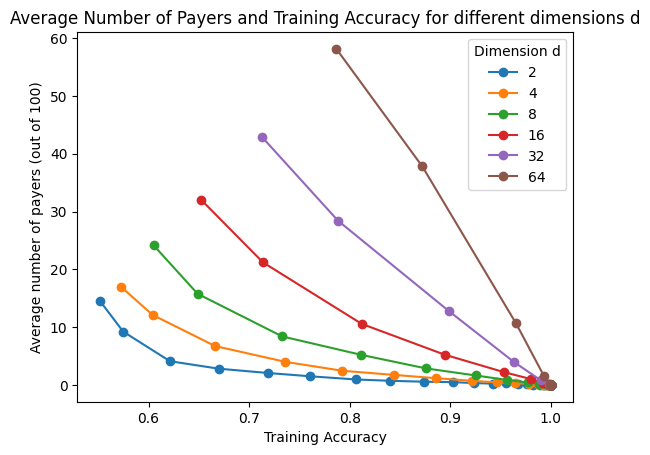

In [ ]:
var = 'mu'
labels = [1,-1]
acc_num_payers(mega_df_mu_full, var,  T, labels)

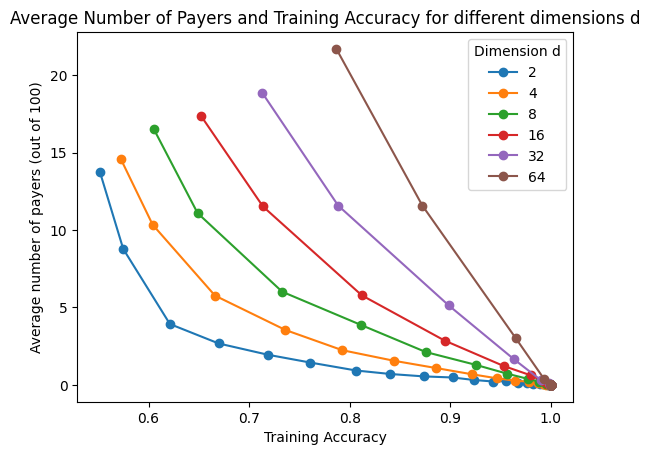

In [22]:
var = 'mu'
labels = [1,-1]
acc_num_payers(mega_df_mu, var, T, labels)

In [32]:
mega_df_mu[(mega_df_mu['d'] == 16) & (mega_df_mu['is_relevant']==1) & (mega_df_mu['critical_v'] > 0)]

,agent,allocation,true_v,critical_v,welfare,utility,is_relevant,is_throw,t,d,mu,valid_acc,label
11900,28,1,1.0,0.741570,1.0,0.258430,1,0,0,16,0.4,0.9425,-1.0
12000,10,1,1.0,0.859808,1.0,0.140192,1,0,0,16,0.3,0.8575,-1.0
12001,29,1,1.0,0.750930,1.0,0.249070,1,0,0,16,0.3,0.8575,-1.0
12100,0,1,1.0,0.697022,1.0,0.302978,1,0,0,16,0.2,0.7850,-1.0
12101,8,1,1.0,0.739055,1.0,0.260945,1,0,0,16,0.2,0.7850,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3713718,76,1,1.0,0.874826,1.0,0.125174,1,0,199,16,0.0,0.5200,1.0
3713719,78,1,1.0,0.862915,1.0,0.137085,1,0,199,16,0.0,0.5200,1.0
3713720,81,1,1.0,0.761510,1.0,0.238490,1,0,199,16,0.0,0.5200,1.0
3713721,91,1,1.0,0.997441,1.0,0.002559,1,0,199,16,0.0,0.5200,1.0


In [ ]:
mega_df_mu[(mega_df_mu['d'] == 8) & (mega_df_mu['is_relevant']==1) & (mega_df_mu['critical_v'] == 0)]

,agent,allocation,true_v,critical_v,welfare,utility,is_relevant,is_throw,t,d,mu,valid_acc,label


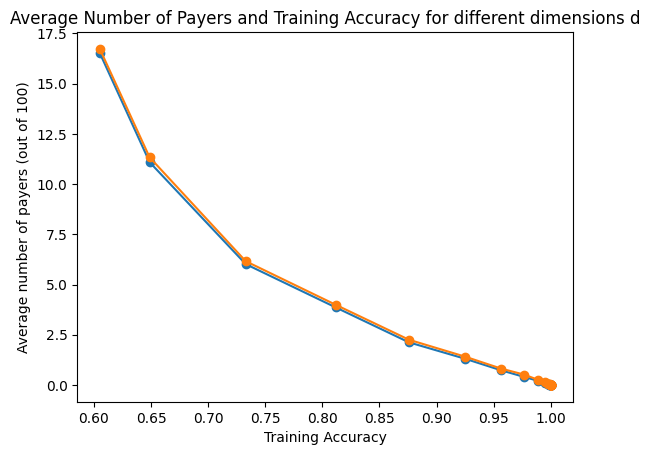

In [37]:
var = 'mu'
labels = [1,-1]
acc_2(mega_df_mu, var, T, [8], labels)

In [ ]:
var = 'beta_neg'
plot_mean_num_payers(mega_df_beta_2, var, labels = [1, -1])
plot_mean_payment(mega_df_beta_2, var, labels = [1, -1])
plot_mean_payment_sd(mega_df_beta_2, var, labels = [1, -1])

#welfare metrics plots
plot_mean_welfare(mega_df_beta_2, var, labels = [1, -1])
plot_mean_welfare_sd(mega_df_beta_2, var, labels = [1, -1])

# utility metrics plots
plot_mean_utility(mega_df_beta_2, var, labels = [1, -1])
plot_mean_utility_sd(mega_df_beta_2, var, labels = [1, -1])


# accuracy metrics plots
plot_mean_accuracy_train(mega_df_beta_2, var, labels = [1, -1])

plot_mean_accuracy_validation(mega_df_beta_2, var, labels = [1, -1])

# percent of points in [0, beta] interval 

plot_percent_relevant(mega_df_beta_2, var, labels = [1, -1])

In [ ]:
var = 'beta_neg'
plot_mean_num_payers(mega_df_beta, var, labels = [1, -1])
plot_mean_payment(mega_df_beta, var, labels = [1, -1])
plot_mean_payment_sd(mega_df_beta, var, labels = [1, -1])

#welfare metrics plots
plot_mean_welfare(mega_df_beta, var, labels = [1, -1])
plot_mean_welfare_sd(mega_df_beta, var, labels = [1, -1])

# utility metrics plots
plot_mean_utility(mega_df_beta, var, labels = [1, -1])
plot_mean_utility_sd(mega_df_beta, var, labels = [1, -1])


# accuracy metrics plots
plot_mean_accuracy_train(mega_df_beta, var, labels = [1, -1])

plot_mean_accuracy_validation(mega_df_beta, var, labels = [1, -1])

# percent of points in [0, beta] interval 

plot_percent_relevant(mega_df_beta, var, labels = [1, -1])

In [ ]:
var = 'sigma_pos'
plot_mean_num_payers(mega_df_sigma, var, labels = [1, -1])
plot_mean_payment(mega_df_sigma, var, labels = [1, -1])
plot_mean_payment_sd(mega_df_sigma, var, labels = [1, -1])

#welfare metrics plots
plot_mean_welfare(mega_df_sigma, var, labels = [1, -1])
plot_mean_welfare_sd(mega_df_sigma, var, labels = [1, -1])

# utility metrics plots
plot_mean_utility(mega_df_sigma, var, labels = [1, -1])
plot_mean_utility_sd(mega_df_sigma, var, labels = [1, -1])


# accuracy metrics plots
plot_mean_accuracy_train(mega_df_sigma, var, labels = [1, -1])

plot_mean_accuracy_validation(mega_df_sigma, var, labels = [1, -1])

# percent of points in [0, beta] interval 

plot_percent_relevant(mega_df_sigma, var, labels = [1, -1])

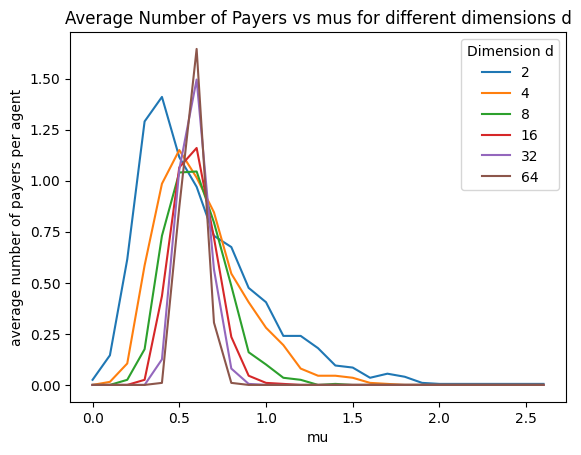

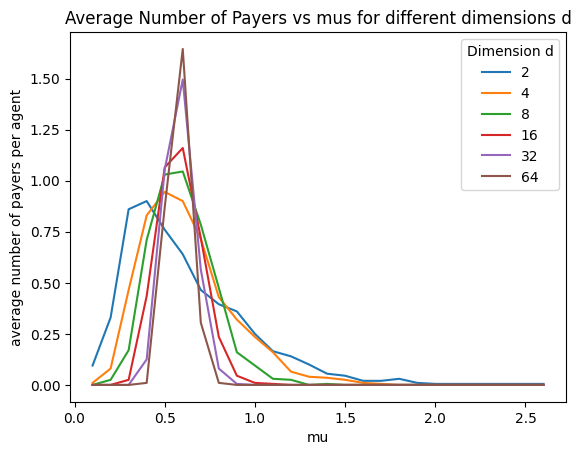

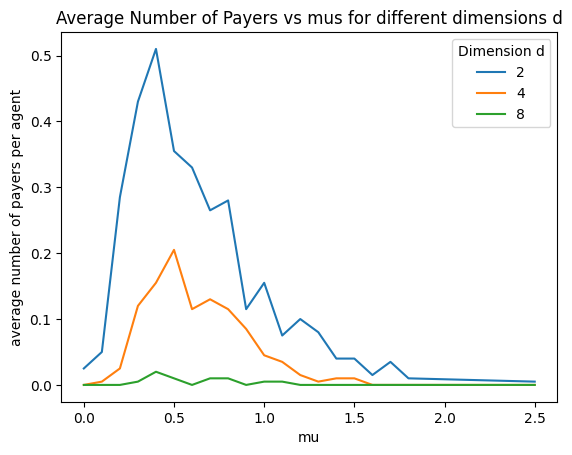

In [14]:
var = 'mu'
plot_mean_num_payers(mega_df_mu, var, labels = [1, -1])
plot_mean_num_payers(mega_df_mu, var, labels = [-1])
plot_mean_num_payers(mega_df_mu, var, labels = [1])


In [ ]:
var = 'mu'
plot_mean_num_payers(mega_df_mu, var, labels = [1, -1])
plot_mean_payment(mega_df_mu, var, labels = [1, -1])
plot_mean_payment_sd(mega_df_mu, var, labels = [1, -1])

#welfare metrics plots
plot_mean_welfare(mega_df_mu, var, labels = [1, -1])
plot_mean_welfare_sd(mega_df_mu, var, labels = [1, -1])

# utility metrics plots
plot_mean_utility(mega_df_mu, var, labels = [1, -1])
plot_mean_utility_sd(mega_df_mu, var, labels = [1, -1])


# accuracy metrics plots
plot_mean_accuracy_train(mega_df_mu, var, labels = [1, -1])

plot_mean_accuracy_validation(mega_df_mu, var, labels = [1, -1])

# percent of points in [0, beta] interval 

plot_percent_relevant(mega_df_mu, var, labels = [1, -1])